# 3.1 — Demonstrations without the spurious feature

**Status (5 October 2026):** designed and tested. The run, stage E on one H200, is pending.

Demonstrations are examples meant to point Qwen to the real, causal signal. The user's argument is that they therefore shouldn't show the shortcut feature, or the noise feature. This notebook tests what changes when they don't (`hiccups/20`).

- **Part 1:** demonstrations without the shortcut feature. The noise feature stays.
- **Part 2:** demonstrations without the shortcut and the noise feature.
- **Queries keep all ten features,** as a new case would in practice. So does the content-free query used for calibration.
- **Baseline:** the same grid with full demonstrations, run alongside on the same GPU.

**What stays the same.**
- Qwen2.5-7B-Instruct, k = 8, the 24 evaluation tasks, all three namings.
- Three seeds (similarity: one).
- ID, covariate and spurious-reversal queries, 20 each.
- random, label_diversity and rule_diversity pick **the same rows in every arm**; only those rows' lines lose features.

**What changes with the mask.**
- **Selection never sees a hidden feature.** feature_range ranks, and similarity measures distance, on the visible features only. counter_prior uses Qwen's zero-shot prior measured on the masked rows.
- **counter_spurious selects on the shortcut,** so it runs only with full demonstrations. There it is the "neutralise the shortcut instead of removing it" reference.
- **The system message drops the measurement count** in all three arms: "Each example lists numeric measurements …". Masked demonstrations show 9 or 8 measurements, the query 10.

This is exploratory and not part of the frozen contrast family.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.utils.config import load_config, resolve_path  # first src import: sets the thread and MPS settings

config = load_config()

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.evaluation import plots
from src.data.demo_mask import DEMO_MASKS, GENERATOR_COLUMNS, hidden_features, visible_features
from src.data.naming import load_lexicons
from src.data.suites import load_suite, suite_dir
from src.data.synthetic_bridge import pool_of
from src.evaluation.analysis import DEMO_MASK_ARMS, cell_metrics, demo_mask_contrasts, summary_table
from src.experiments.synth_grid import GridRunner, Unit
from src.inference.prompts import completion_prompt

manifest = load_suite("eval", config)
entries = {t["task_id"]: t for t in manifest["tasks"]}
RESULTS = resolve_path(config.paths.results)
DM = Path(os.environ.get("NB31_RESULTS", RESULTS / "h200" / "demo_mask"))   # stage E output, copied back from the pod
plots.use_style()
ARMS = list(DEMO_MASK_ARMS)                  # none, spurious, spurious_noise


class TextOnly:
    """Renders prompts without a model, to inspect what each arm shows."""
    def render(self, system, demo_lines, query_line):
        return completion_prompt(system, demo_lines, query_line)


def grid_for(mask, naming_lexicons=load_lexicons("final")):
    return GridRunner(TextOnly(), "qwen2.5-7b-instruct", suite_dir("eval", config), manifest,
                      base_seed=config.selection.base_seed, envs=["id", "covariate", "spurious_reversal"],
                      queries_per_env=20, lexicons=naming_lexicons, demo_mask=mask, system_n_features=None)


grids = {m: grid_for(m) for m in ARMS}

## 1. Which features are hidden: ground truth, not estimation

The generator creates the shortcut as its column 8 and the noise feature as its column 9, before the features are shuffled for display. Each task's manifest records that shuffle (the column-role permutation). So the displayed name of each hidden feature is **looked up**, never estimated from the data.

The first table checks the lookup against the roles the manifest stores.

The second table checks it against the data itself, for every task:
- **The values:** the hidden shortcut must be the one displayed feature holding the generator's own shortcut values. These are saved before the shuffle as `spurious_raw`, so the correlation must be exactly 1.
- **The behaviour:** it must be the feature whose agreement with the label collapses between ID and spurious-reversal queries, since spurious reversal changes nothing else.
- **The noise feature:** it must be unrelated to the label.

In [2]:
print("generator columns:", GENERATOR_COLUMNS)
rows = []
for tid, e in entries.items():
    perm = e["permutation"]
    rows.append({"task": tid, "domain": e["domain"], "family": e["family"],
                 "shortcut shown as": f"f{perm[GENERATOR_COLUMNS['spurious']]}",
                 "noise shown as": f"f{perm[GENERATOR_COLUMNS['noise']]}",
                 "matches manifest roles": hidden_features(e, "spurious_noise") == (e["roles"]["spurious"], e["roles"]["noise"])})
lookup = pd.DataFrame(rows)
assert lookup["matches manifest roles"].all()
display(lookup)

from src.data.synthetic_bridge import FEATURE_NAMES, load_task_frame
checks = []
for tid, e in entries.items():
    df = load_task_frame(suite_dir("eval", config), tid)
    shortcut, noise = hidden_features(e, "spurious_noise")
    corr = {f: abs(np.corrcoef(df[f], df["spurious_raw"])[0, 1]) for f in FEATURE_NAMES}
    def agree(env, f):
        d = df[(df["env"] == env) & (df["split"] != "pool")]
        return float((np.sign(e["spurious_direction"] * d[f]) == np.sign(2 * d["y_clean"] - 1)).mean())
    drop = {f: agree("id", f) - agree("spurious_reversal", f) for f in FEATURE_NAMES}
    pool = df[df["split"] == "pool"]
    checks.append({"task": tid, "hidden shortcut": shortcut,
                   "holds the generator's shortcut values": max(corr, key=corr.get),
                   "corr": round(corr[shortcut], 6),
                   "agreement drop, ID to reversal": round(drop[shortcut], 2),
                   "largest drop of any other feature": round(max(v for f, v in drop.items() if f != shortcut), 2),
                   "hidden noise": noise, "noise |corr| with label": round(abs(np.corrcoef(pool[noise], pool["label"])[0, 1]), 3)})
checks = pd.DataFrame(checks)
assert (checks["hidden shortcut"] == checks["holds the generator's shortcut values"]).all()
assert (checks["agreement drop, ID to reversal"] > checks["largest drop of any other feature"]).all()
checks

generator columns: {'spurious': 8, 'noise': 9}


,task,domain,family,shortcut shown as,noise shown as,matches manifest roles
0,eval_0000,loan,linear,f4,f8,True
1,eval_0001,medical,linear,f0,f6,True
2,eval_0002,loan,linear,f9,f6,True
3,eval_0003,medical,linear,f0,f3,True
4,eval_0004,loan,linear,f9,f4,True
5,eval_0005,medical,linear,f3,f7,True
6,eval_0006,loan,linear,f0,f8,True
7,eval_0007,medical,linear,f0,f9,True
8,eval_0008,loan,linear,f4,f6,True
9,eval_0009,medical,linear,f3,f8,True


,task,hidden shortcut,holds the generator's shortcut values,corr,"agreement drop, ID to reversal",largest drop of any other feature,hidden noise,noise |corr| with label
0,eval_0000,f4,f4,1.0,0.64,0.14,f8,0.009
1,eval_0001,f0,f0,1.0,0.70,0.06,f6,0.017
2,eval_0002,f9,f9,1.0,0.66,0.09,f6,0.089
3,eval_0003,f0,f0,1.0,0.85,0.15,f3,0.038
4,eval_0004,f9,f9,1.0,0.68,0.06,f4,0.004
5,eval_0005,f3,f3,1.0,0.68,0.11,f7,0.009
6,eval_0006,f0,f0,1.0,0.68,0.09,f8,0.072
7,eval_0007,f0,f0,1.0,0.81,0.08,f9,0.028
8,eval_0008,f4,f4,1.0,0.76,0.15,f6,0.077
9,eval_0009,f3,f3,1.0,0.65,0.06,f8,0.017


## 2. What the prompts look like in each arm

Task `eval_0000`, flipped names, label_diversity at seed 0. Its shortcut feature is called *form version* and its noise feature *mailing batch number*. The first two demonstrations and the first ID query are shown in each arm; the query is the same in all three.

In [3]:
unit = Unit("qwen2.5-7b-instruct", "flipped", "eval_0000", "label_diversity", "gold", 8, 0)
for mask in ARMS:
    (g,) = grids[mask].prompt_groups(unit)
    print(f"=== {mask}: hidden {list(hidden_features(entries['eval_0000'], mask)) or 'nothing'}")
    print("system:", grids[mask].system_text("eval_0000", "flipped")[:110], "...")
    for line in g["demo"]["lines"][:2]:
        print("  demo :", line)
    print("  query:", g["suffixes"][0].strip())
    print()

=== none: hidden nothing
system: You are a classifier. Each example describes a loan applicant with measurements and a label: 1 means the loan  ...
  demo : office floor number: 0.92; loan officer ID: -1.12; applicant ID last digit: 1.79; credit card utilisation: 0.35; form version: 1.59; hour of submission: -0.82; days since form printed: 0.72; credit score: 0.56; mailing batch number: -0.24; past defaults: 2.03 -> 1
  demo : office floor number: -1.19; loan officer ID: -0.15; applicant ID last digit: -1.51; credit card utilisation: -0.32; form version: 1.00; hour of submission: -0.25; days since form printed: -1.01; credit score: -1.23; mailing batch number: -1.28; past defaults: 0.36 -> 1
  query: office floor number: 1.25; loan officer ID: 0.19; applicant ID last digit: 0.10; credit card utilisation: -0.04; form version: -0.83; hour of submission: 0.20; days since form printed: 0.01; credit score: 0.36; mailing batch number: -0.31; past defaults: 0.65 ->

=== spurious: hidden ['f4'

## 3. Selection never sees a hidden feature

Four checks over all 24 tasks:
1. random, label_diversity and rule_diversity pick the same rows in every arm, at every seed.
2. feature_range covers the shortcut in every task with full demonstrations (`hiccups/19`), and never once it is hidden.
3. similarity measures distance on the visible features only.
4. **The shortcut's agreement with the label in each arm's chosen rows.** The masked arms don't *show* the shortcut, but this measures what the rows would have taught. It changes only where selection used to read the shortcut.

1. same rows in every arm: 216 of 216 (task, strategy, seed) sets


2. feature_range: tasks whose 3 coverage features include ...


,covers shortcut,covers noise
arm,,
none,24,0
spurious,0,2
spurious_noise,0,0


3. similarity distance in arm 'none' uses 10 features: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9']
3. similarity distance in arm 'spurious' uses 9 features: ['f0', 'f1', 'f2', 'f3', 'f5', 'f6', 'f7', 'f8', 'f9']
3. similarity distance in arm 'spurious_noise' uses 8 features: ['f0', 'f1', 'f2', 'f3', 'f5', 'f6', 'f7', 'f9']


4. share of chosen rows where the shortcut agrees with the label (seed 0, abstract names)


arm,none,spurious,spurious_noise
strategy,,,
feature_range,0.615,0.802,0.812
label_diversity,0.812,0.812,0.812
rule_diversity,0.891,0.891,0.891


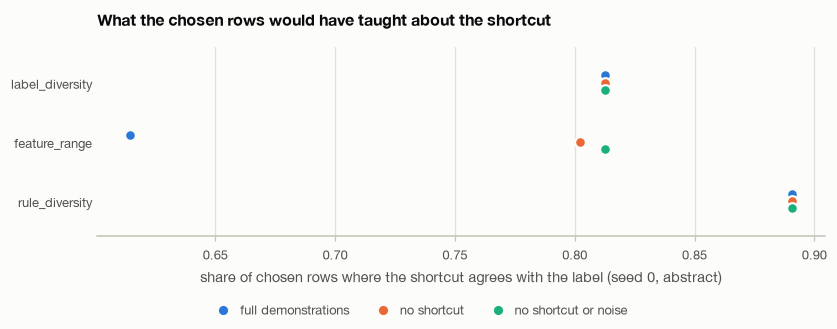

In [4]:
same_rows = []
for tid in entries:
    for strategy in ("random", "label_diversity", "rule_diversity"):
        for seed in range(3):
            u = Unit("qwen2.5-7b-instruct", "abstract", tid, strategy, "gold", 8, seed)
            ids = [grids[m].prompt_groups(u)[0]["demo"]["ids"] for m in ARMS]
            same_rows.append(ids[0] == ids[1] == ids[2])
print(f"1. same rows in every arm: {sum(same_rows)} of {len(same_rows)} (task, strategy, seed) sets")

cover = []
for tid, e in entries.items():
    u = Unit("qwen2.5-7b-instruct", "abstract", tid, "feature_range", "gold", 8, 0)
    for m in ARMS:
        feats = grids[m].prompt_groups(u)[0]["demo"]["meta"]["features"]
        cover.append({"task": tid, "arm": m, "covers shortcut": e["roles"]["spurious"] in feats,
                      "covers noise": e["roles"]["noise"] in feats})
cover = pd.DataFrame(cover)
print("2. feature_range: tasks whose 3 coverage features include ...")
display(cover.groupby("arm")[["covers shortcut", "covers noise"]].sum())

u = Unit("qwen2.5-7b-instruct", "abstract", "eval_0000", "similarity", "gold", 8, 0)
for m in ARMS:
    cols = grids[m].context(u, pool_of(grids[m].frame("eval_0000"))).feature_cols
    print(f"3. similarity distance in arm {m!r} uses {len(cols)} features: {cols}")

agree = []
for tid in entries:
    pool = pool_of(grids["none"].frame(tid))
    for strategy in ("label_diversity", "feature_range", "rule_diversity"):
        for m in ARMS:
            u = Unit("qwen2.5-7b-instruct", "abstract", tid, strategy, "gold", 8, 0)
            ids = grids[m].prompt_groups(u)[0]["demo"]["ids"]
            agree.append({"strategy": strategy, "arm": m, "agree": pool.loc[ids, "agree_obs"].mean()})
print("4. share of chosen rows where the shortcut agrees with the label (seed 0, abstract names)")
agree_df = pd.DataFrame(agree)
display(agree_df.pivot_table(index="strategy", columns="arm", values="agree").round(3)[ARMS])
am = agree_df.groupby(["strategy", "arm"])["agree"].mean().reset_index()
fig, ax = plt.subplots(figsize=(7.5, 2.9), layout="constrained")
plots.dots(ax, am, y="strategy", x="agree", hue="arm", y_order=["label_diversity", "feature_range", "rule_diversity"],
           hue_order=ARMS, xlabel="share of chosen rows where the shortcut agrees with the label (seed 0, abstract)")
plots.legend_below(fig, ARMS, plots.SERIES)
ax.set_title("What the chosen rows would have taught about the shortcut")
plt.show()

**Reading the chart.**
- **label_diversity and rule_diversity** pick the same rows in every version, so their three dots coincide.
- **feature_range** stops over-representing rows where the shortcut disagrees once it can't see the shortcut (about 0.62 → 0.80). Its masked versions are therefore not just "the same rows, one feature fewer".

## 4. How it runs

Stage E of `scripts/run_p4_pod.sh` runs on one H200, with 8 worker processes sharing the GPU through NVIDIA MPS:
1. **Pool priors,** for counter_prior: Qwen's zero-shot answer on every pool row, under each arm's system message and with the arm's hidden features removed. That is 3 arms × 24 tasks × 3 namings × 256 rows.
2. **The three grids.**
   - Full demonstrations: zero_shot, random, label_diversity, feature_range, rule_diversity, counter_spurious and counter_prior, plus similarity at one seed.
   - Each masked arm: the same without zero_shot and counter_spurious.

The estimate is about 310,000 forward passes, roughly 45 minutes including setup. The results land in `results/v3/synthetic/h200/demo_mask/` (`grid_<arm>.parquet`, `pool_prior_<model>_<arm>.parquet`).

```bash
bash scripts/run_p4_pod.sh E
```

In [5]:
HAVE_RESULTS = all((DM / f"grid_{m}.parquet").exists() for m in ARMS)
if HAVE_RESULTS:
    arms = {m: pd.read_parquet(DM / f"grid_{m}.parquet") for m in ARMS}
    for m, df in arms.items():
        print(f"{m:15s} {len(df):6d} rows, {df.unit_key.nunique():5d} units, strategies {sorted(df.strategy.unique())}")
    cells = {m: cell_metrics(df) for m, df in arms.items()}
else:
    print(f"Results pending: run stage E (scripts/run_p4_pod.sh E) and copy {DM.relative_to(RESULTS)} back.")

Results pending: run stage E (scripts/run_p4_pod.sh E) and copy h200/demo_mask back.


## 5. Part 1: demonstrations without the shortcut

**What to expect, written before the run.**
- **If Qwen learns the shortcut from the demonstrations,** hiding it should lower ID AUROC, since the shortcut helps on ID queries, and raise spurious-reversal AUROC. The ID − reversal gap should shrink (M4 below 0).
- **If Qwen instead reads the shortcut from the query through its "bigger → 1" prior,** the gap stays, with opposite signs for the two spurious directions σ_t (section 7).

**The contrasts.** M1 is no shortcut − full; M4 is the change in the ID − reversal gap; M5 is removing the shortcut (label_diversity, masked) against neutralising it (counter_spurious, full). All are paired by task, seed and query, with hierarchical-bootstrap 95% intervals.

In [6]:
if HAVE_RESULTS:
    con = demo_mask_contrasts(arms)
    STRATS = [s for s in plots.STRATEGIES if s in set(con.strategy)]
    levels = pd.concat([c[c.label_mode == "gold"].groupby(["strategy", "naming", "env", "task_id"])["auroc"].mean()
                          .groupby(["strategy", "naming", "env"]).mean().reset_index().assign(arm=m)
                        for m, c in cells.items()], ignore_index=True)
    display(levels.pivot_table(index=["naming", "strategy"], columns=["env", "arm"], values="auroc").round(3))
    levels["panel"] = levels["naming"] + " · " + levels["env"].map(plots.label)
    fig = plots.facet_dots(levels, facet="panel", y="strategy", x="auroc", hue="arm",
                           facet_order=[f"{n} · {plots.label(e)}" for n in plots.NAMINGS for e in plots.ENVS],
                           y_order=[s for s in plots.STRATEGIES if s in set(levels.strategy)], hue_order=ARMS,
                           ref=0.5, ref_label="chance", xlabel="AUROC, mean over 24 tasks", ncols=3,
                           title="Mean AUROC with full demonstrations, without the shortcut, and without the shortcut or noise")
    plt.show()

    def flag(d):
        return d.assign(excludes_zero=(d.ci_low > 0) | (d.ci_high < 0))

    def forest_by_env(cid, xlabel, title):
        d = flag(con[con.id == cid])
        display(d.drop(columns=["label"]).round(3).reset_index(drop=True))
        fig = plots.facet_dots(d, facet="env", y="strategy", x="estimate", hue="naming", facet_order=plots.ENVS,
                               y_order=STRATS, hue_order=plots.NAMINGS, lo="ci_low", hi="ci_high",
                               filled="excludes_zero", ref=0, ref_label="no change", hollow_note=True,
                               xlabel=xlabel, title=title)
        plt.show()

    forest_by_env("M1", "AUROC, no shortcut minus full", "M1: what removing the shortcut from the demonstrations changes")

    m4 = flag(con[con.id == "M4"])
    display(m4.drop(columns=["label"]).round(3).reset_index(drop=True))
    fig, ax = plt.subplots(figsize=(7.5, 3.9), layout="constrained")
    plots.dots(ax, m4, y="strategy", x="estimate", hue="naming", y_order=STRATS, hue_order=plots.NAMINGS,
               lo="ci_low", hi="ci_high", filled="excludes_zero", ref=0, ref_label="gap unchanged",
               xlabel="change in the ID − spurious-reversal gap: no shortcut minus full")
    plots.legend_below(fig, plots.NAMINGS, plots.SERIES, hollow_note=True)
    ax.set_title("M4: does removing the shortcut shrink the cost of spurious reversal?")
    plt.show()

    m5 = flag(con[con.id == "M5"])
    display(m5.drop(columns=["label"]).round(3).reset_index(drop=True))
    fig, ax = plt.subplots(figsize=(7.5, 2.9), layout="constrained")
    plots.dots(ax, m5, y="env", x="estimate", hue="naming", y_order=list(plots.ENVS), hue_order=plots.NAMINGS,
               lo="ci_low", hi="ci_high", filled="excludes_zero", ref=0, ref_label="no difference",
               xlabel="AUROC: label_diversity without the shortcut minus counter_spurious with it")
    plots.legend_below(fig, plots.NAMINGS, plots.SERIES, hollow_note=True)
    ax.set_title("M5: removing the shortcut against neutralising it")
    plt.show()
else:
    print("Results pending.")

Results pending.


**Reading the charts.**
- **The first chart** puts the three versions side by side for every strategy, naming and environment.
- **The forest charts** show each paired difference with its 95% interval; filled dots exclude 0. Look for three things:
  - **M1:** a drop on ID and a gain under spurious reversal.
  - **M4:** a gap that shrinks, so the dots sit left of 0.
  - **M5:** whether removing the shortcut beats neutralising it.

## 6. Part 2: without the shortcut and the noise feature

M2 is no shortcut or noise − full; M3 is what removing the noise feature adds on top of removing the shortcut. The noise feature is unrelated to the label by construction, so M3 should be close to 0. A clear M3 would mean Qwen was reading the noise feature.

In [7]:
if HAVE_RESULTS:
    forest_by_env("M2", "AUROC, no shortcut or noise minus full", "M2: removing the shortcut and the noise feature")
    forest_by_env("M3", "AUROC, no shortcut or noise minus no shortcut", "M3: what also removing the noise feature adds")
else:
    print("Results pending.")

Results pending.


## 7. Can Qwen still read the shortcut from the query?

The masked arms never show the shortcut in a demonstration, but every query still has it. Qwen's zero-shot habit is "bigger number → 1" (`hiccups/09`), so it can still be pulled by the shortcut's value in the query:
- **σ_t = +1 tasks:** a large shortcut value goes with label 1 on ID queries. The habit then helps on ID and hurts under reversal.
- **σ_t = −1 tasks:** the habit hurts on ID and helps under reversal.

A gap that keeps opposite signs for the two directions in the masked arms is shortcut use through the prior, not through the demonstrations.

In [8]:
if HAVE_RESULTS:
    sigma = {tid: e["spurious_direction"] for tid, e in entries.items()}
    rows = []
    for m, c in cells.items():
        c = c[(c.label_mode == "gold") & (c.strategy.isin(["random", "label_diversity"]))]
        per_task = c.groupby(["strategy", "naming", "task_id", "env"])["auroc"].mean().unstack("env")
        gap = (per_task["id"] - per_task["spurious_reversal"]).rename("gap").reset_index()
        gap["sigma_t"] = gap.task_id.map(sigma)
        gap["arm"] = m
        rows.append(gap)
    gaps = pd.concat(rows)
    display(gaps.pivot_table(index=["strategy", "naming", "sigma_t"], columns="arm", values="gap")[ARMS].round(3))
    gm = gaps.groupby(["strategy", "naming", "sigma_t", "arm"])["gap"].mean().reset_index()
    gm["row"] = gm["strategy"] + " · " + gm["naming"]
    directions = {1: "σ = +1: Qwen's prior agrees with the shortcut", -1: "σ = −1: the prior opposes it"}
    gm["direction"] = gm["sigma_t"].map(directions)
    fig = plots.facet_dots(gm, facet="direction", y="row", x="gap", hue="arm", facet_order=list(directions.values()),
                           y_order=[f"{s} · {n}" for s in ("random", "label_diversity") for n in plots.NAMINGS],
                           hue_order=ARMS, ref=0, ref_label="no gap", xlabel="AUROC, ID minus spurious reversal",
                           title="Does the shortcut still act through the query?")
    plt.show()
else:
    print("Results pending.")

Results pending.


**Reading the chart.** It shows the ID − spurious-reversal gap per arm, split by the shortcut's direction. In the P4 grid (notebook 05, section 3), the gap was large for σ = +1 tasks and near 0 or negative for σ = −1, even for zero-shot.
- **The gap still splits like that in the masked versions** → the shortcut acts through the query and Qwen's prior.
- **The gap closes in both directions** → the demonstrations were teaching it.

## 8. What we found

*Written after the run.*